In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'Customer Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Describing the data columns :
### real numerical columns:- MonthlyCharges,TotalCharges
### discrete numerical columns:- tenure,SeniorCitizen
# Categorical column:-
### gender,partner,dependants,PhoneService,MultipleLines,InternetService,OnlineSecurity,DeviceProtection,
### TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod, Churn.
# Identifier column:- 
### customerID.      

# Here identifier column should be dropped

In [9]:
df = df.drop(columns=['customerID'])

# Data Cleaning 

In [10]:
df['TotalCharges'].dtype

dtype('O')

## Here it shows the totalcharges as object datatype. So, we have to convert this to numerical columns

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors ='coerce')   #errors='coerce' converts invalid values (like blank spaces, empty strings, or text) into NaN instead of raising an error.

# Check missing value

In [12]:
df.isnull().any()  # any() use for True or false 

gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges         True
Churn               False
dtype: bool

In [13]:
df.isnull().sum()  # sum() used for 0 and 1 (count)

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

# * There are no missing values in the above dataset

# Checking Outliers

### Only **`tenure`**, **`MonthlyCharges`**, and **`TotalCharges`** are continuous numerical features, so they are used for statistical analysis and visualizations. `SeniorCitizen` is binary (0/1), so it is treated as a categorical variable.

In [14]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['MonthlyCharges'] < lower) | (df['MonthlyCharges'] > upper)]
print(len(outliers))

0


Text(0.5, 1.0, 'MONTHLYCHARGES')

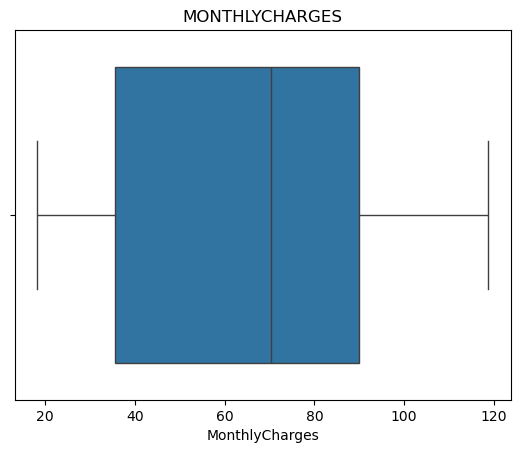

In [15]:
sns.boxplot(df,x = 'MonthlyCharges')
plt.title('MONTHLYCHARGES')

In [16]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['TotalCharges'] < lower) | (df['TotalCharges'] > upper)]
print(len(outliers))

0


Text(0.5, 1.0, 'TOTALCHARGES')

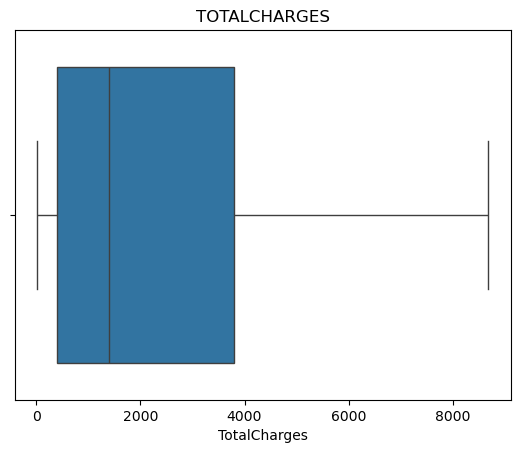

In [17]:
sns.boxplot(df,x = 'TotalCharges')
plt.title('TOTALCHARGES')

In [18]:
Q1 = df['tenure'].quantile(0.25)
Q3 = df['tenure'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['tenure'] < lower) | (df['tenure'] > upper)]
print(len(outliers))

0


Text(0.5, 1.0, 'TENURE')

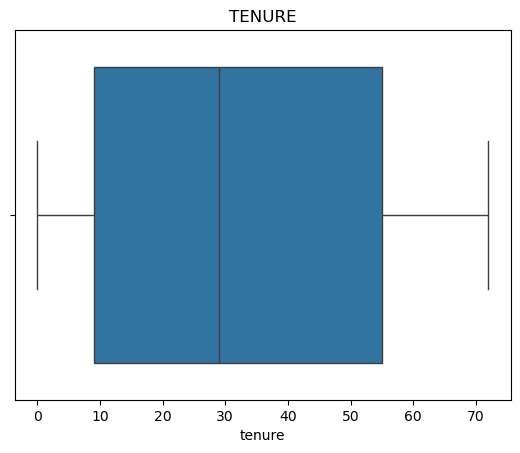

In [19]:
sns.boxplot(df,x = 'tenure')
plt.title('TENURE')

### Therefore in the above data there are no outliers are present

# Checking Duplicates 

In [20]:
df.duplicated().sum()

np.int64(22)

### There are 22 duplicate rows in this dataset (found after removing customerID).
  I have cleaned the data by checking missing values, duplicates, and outliers, removed unnecessary columns, and converted the data types of the columns which needed it.

# Exploratary Data Analysis

In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Tenure Distribution

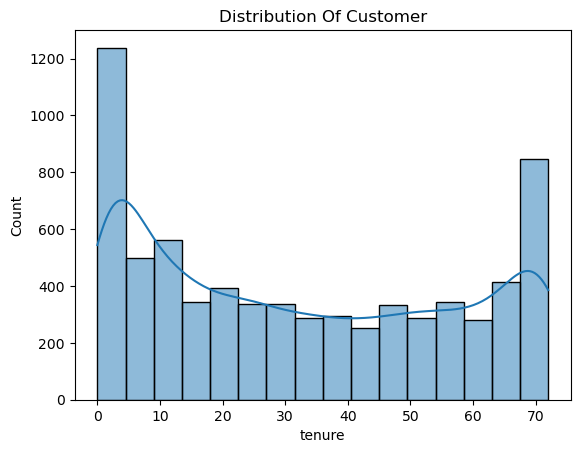

In [55]:
sns.histplot(df['tenure'],kde = 'True')
plt.title("Distribution Of Customer")
plt.show()

## Observation:
   ### - Most customers have two tenure.
   ### - The number of customers decreases as tenure increases.

# MonthlyCharges Distribution

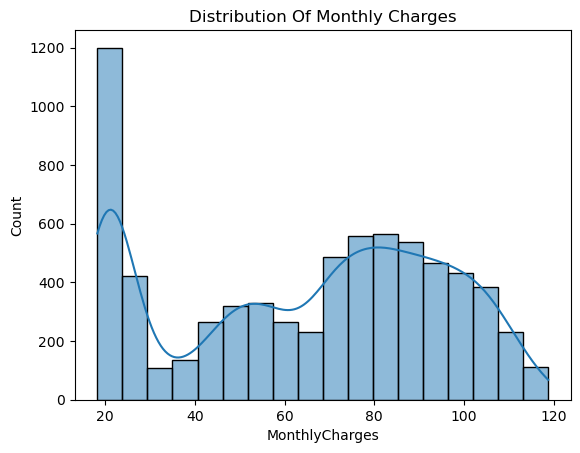

In [23]:
sns.histplot(df['MonthlyCharges'],kde = 'True')
plt.title("Distribution Of Monthly Charges")
plt.show()

## Observation
   ### - Monthly Charges are spread across different price ranges
   ### - Customers are distributed across low,medium and high categories

# TotalCharges Distribution

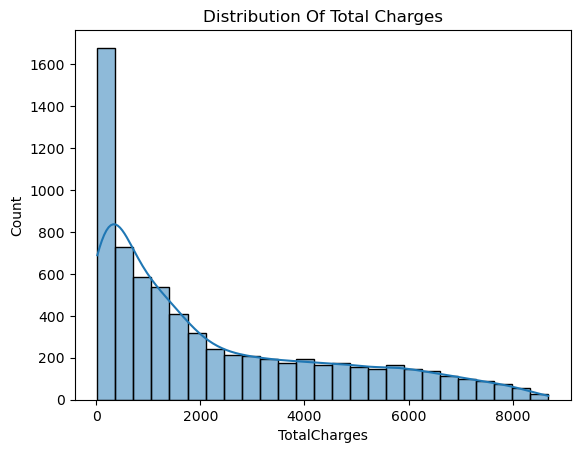

In [24]:
sns.histplot(df['TotalCharges'],kde = 'True')
plt.title("Distribution Of Total Charges")
plt.show()

## Observation
   ### - The distribution is positively skewed.
   ### - Most Customer have lower total charges, while a few customers have very high total charges 

## Percentage of customer churn

In [25]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### - Here,the retained customers are above 5000 and churn customers are around 1800

In [26]:
df['Churn'].value_counts()/len(df)*100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

## Here churn percetage is 26.5%.
## Therefore 26.5% customers from the Telecom Companies.

<function matplotlib.pyplot.show(close=None, block=None)>

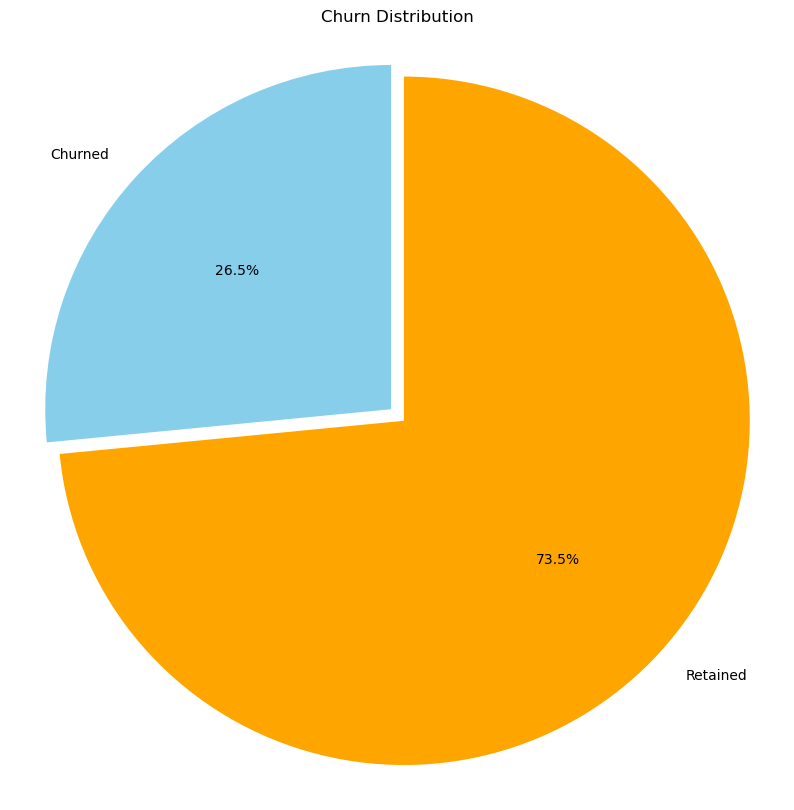

In [27]:
labels = ['Churned','Retained']
sizes = [1869,5174]
colors = ['skyblue','orange']
plt.figure(figsize=(10,10))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0.05,0)
)
plt.title('Churn Distribution')
plt.axis('equal')
plt.show

### - It is the visual representation of customer churned data

# Tenure VS Churn 

In [28]:
df['Tenure_Group'] = pd.cut(df['tenure'],bins = [0,12,24,48,72],labels = ['8-12 Months','13-24 Months','25-48 Months','49-72 Months'])

In [29]:
pd.crosstab(df['Tenure_Group'],df['Churn'],normalize = 'index')*100

Churn,No,Yes
Tenure_Group,,
8-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


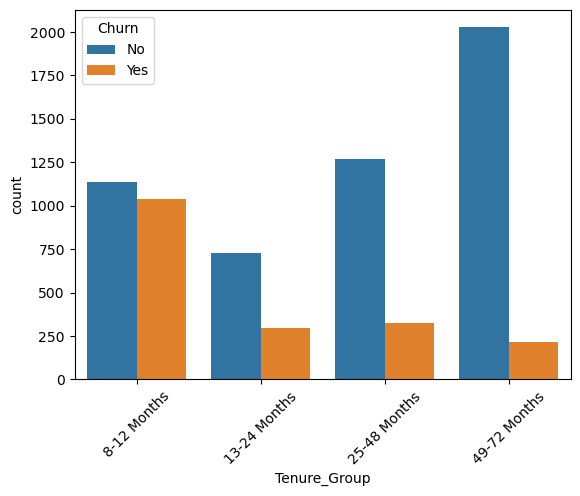

In [30]:
sns.countplot(x ='Tenure_Group',hue = 'Churn',data = df)
plt.xticks(rotation = 45)
plt.show()

## Observation
   ### - Here 0-12Months has the highest churn and the customers with tenure 49-72months are having low churn.

# Insights

### - Customers in 0-12Months have the highest churn.
### - Churn decreases as churn increases.
### - Longterm customers are more loyal.

# MonthlyCharges VS Churn

In [31]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

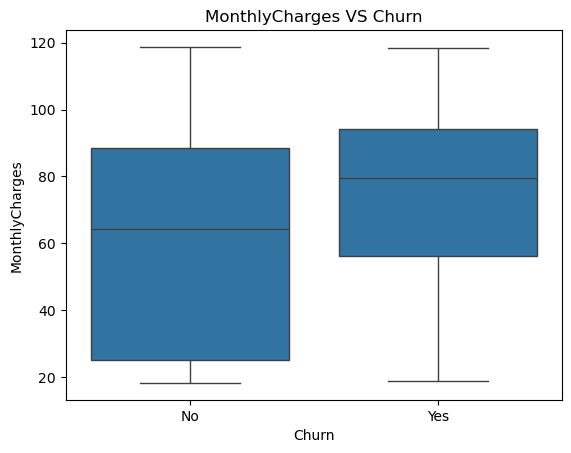

In [32]:
sns.boxplot(df,x ='Churn',y = 'MonthlyCharges')
plt.title('MonthlyCharges VS Churn')
plt.show()

### - Here we can observe that the average monthly charges with respect to churn.
### - The average monthly charges of retained customers is approximately 61.2
### - The average monthly charges of churned customers is approximately 74.5

# TotalCharges VS Churn

In [33]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64

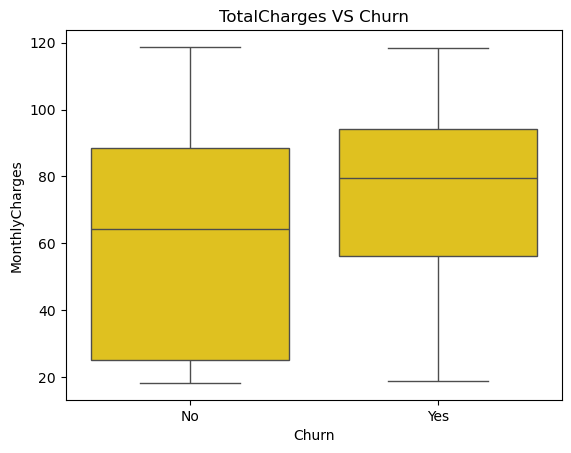

In [34]:
sns.boxplot(df,x ='Churn',y = 'MonthlyCharges',color= 'gold')
plt.title('TotalCharges VS Churn')
plt.show()

### - Here we can observe the average of totalcharges with respected churn.
### - The customers who are not churned are able to pay large amount, so they would pay high amount compared to churned.

# Gender VS Churn 

In [35]:
pd.crosstab(df['gender'],df['Churn'],normalize='index')*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


### - There is no difference in this Gender column.
### - Male and Female customers are same equality Retained and Churned.

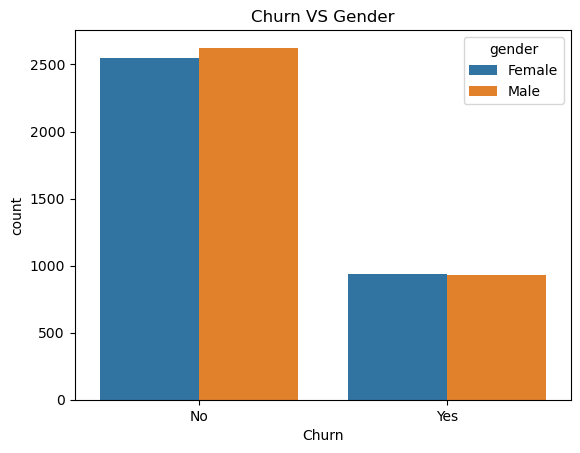

In [36]:
sns.countplot(x ='Churn',hue = 'gender',data = df)
plt.title("Churn VS Gender")
plt.show()

## Observation:
  ### - here,there is no much difference between male and female in both cases(Churned and Retained).

## Insights:
   ### - The gender are not effected in churn.
   ### - Male and Female Customers are similarly Retained and Churned 

# Partner VS Churn

In [37]:
pd.crosstab(df['Partner'],df['Churn'],normalize='index')*100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


### - Here, The Customer without partners are more churned and also slightly more retained customers are with partners only

Text(0.5, 1.0, 'CHURN VS PARTNER')

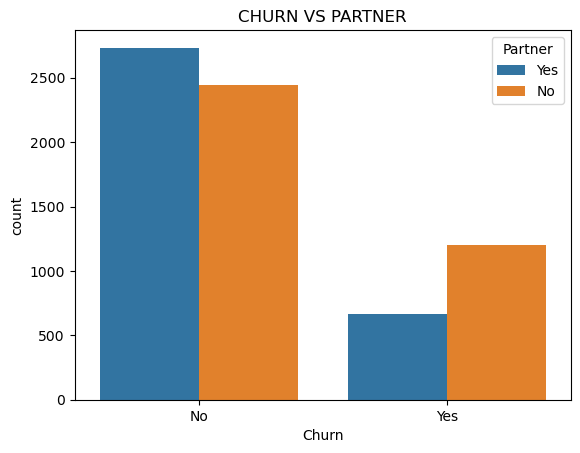

In [38]:
sns.countplot(x ='Churn',hue = 'Partner',data = df)
plt.title("CHURN VS PARTNER")

## Observation:
   ### - Here we can observe that the customers having partners are more Retained customers also and they are less Churned.
   ### - The customers without partners are Churned more.
   ### - The customers without partners are less Retained and highly Churned compared to the customers with partners.

## Insights:
   ### - There is not affected on Churn from the customers having partners.
   ### - Customers without partners show a higher tendency to leave the company.

# Dependents VS Churn

In [39]:
pd.crosstab(df['Dependents'],df['Churn'],normalize='index')*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


### - Here the customers without Dependents are heavily Churned and also customers with Dependents are very less Churned.

Text(0.5, 1.0, 'CHURN VS DEPENDENTS')

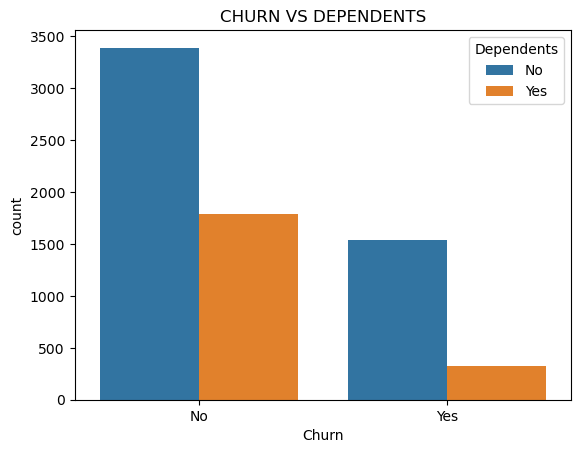

In [40]:
sns.countplot(x ='Churn',hue = 'Dependents',data = df)
plt.title("CHURN VS DEPENDENTS")

## Observation:
   ### - Here we can observe that the customers with dependents are more Retained ones and also there is less Churn rate.
   ### - The customers without dependents are highly Churned.

## Insights:
   ### - Having dependents appears to be associated with better customer retention.
   ### - Customers with dependents demonstrate more stable retention.
   ### - Customers without dependents are more likely to leave the telecom company.
   ### - The higher number of retained customers without dependents is likely due to the larger size of that customers group, not necessarily, because they have a better retention rate.

# InternetService VS Churn

In [41]:
pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### - We can observe that customers without internet service has very less churn and also high retention rate compared to other categories and also DSL also has better retention rate and less churn rate compare to fiber optic service.
### - Fiber Optic service has high churn rate compared to other categories and also very less retention rate. 

Text(0.5, 1.0, 'CHURN VS INTERNETSERVICE')

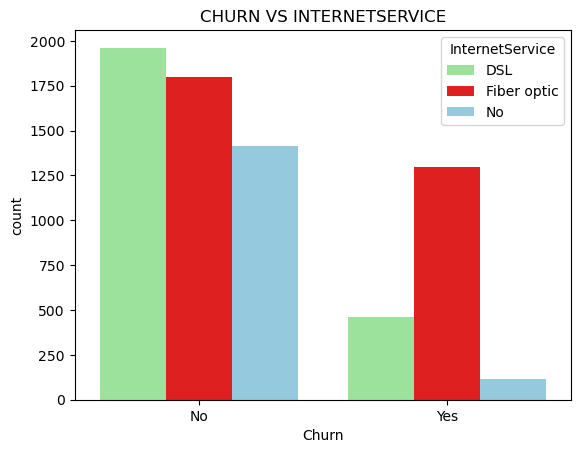

In [42]:
sns.countplot(x ='Churn',hue = 'InternetService',data = df, palette=('lightgreen','red','skyblue'))
plt.title("CHURN VS INTERNETSERVICE")

### OBSERVATIONS:
- WE CAN OBSERVE THAT CUSTOMERS WITHOUT INTERNET SERVICE HAS VERY LESS CHURN AND ALSO HIGH RETENTION RATE COMPARED TO OTHER CATEGORIES
- AND DSL ALSO HAS BETTER RETENTION RATE AND LESS CHURN RATE COMPARE TO FIBER OPTIC SERVICE
- FIBER OPTIC SERVICE HAS HIGH CHURN RATE COMPARED TO OTHER CATEGORIES AND ALSO VERY LESS RETENTION RATE

### INSIGHTS:
- CUSTOMERS WITH FIBER OPTIC SERVICE HAS THE HIGHEST CHURN RATE COMPARED TO OTHER INETERNET SERVICE CATEGORIES
- DSL CUSTOMERS IS HAVING HIGH CHURN RATE COMPARED TO THE CUSTOMERS WITHOUT INTERNET SERVICE
- CUSTOMERS WITHOUT INTERNET SERVICE HAS LESS CHURN AND THEY ARE THE HIGHLY RETAINED CUSTOMERS
- INTERNET SERVICE HAS A SIGNIFICANT IMPACT ON THE CUSTOMER CHURN

# OnlineSecurity VS Churn

In [43]:
pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


### - We can observe that the customers without OnlineSecurity are churned more.
### - Also with not having any internet has been churned less and they are less.
### - The customers with OnlineSecurity are Churned less and also retention rate is high. 

Text(0.5, 1.0, 'CHURN VS ONLINESSECURITY')

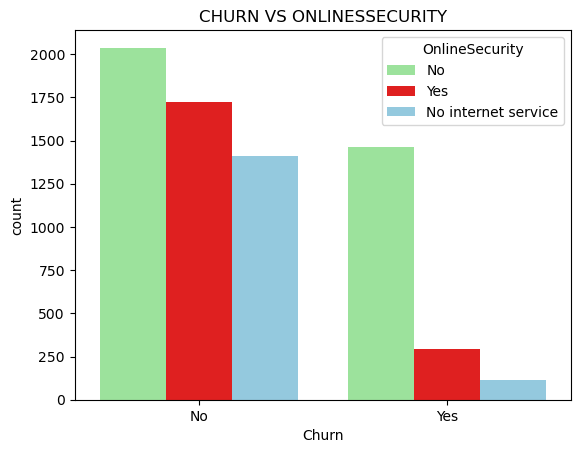

In [44]:
sns.countplot(x ='Churn',hue = 'OnlineSecurity',data = df, palette=('lightgreen','red','skyblue'))
plt.title("CHURN VS ONLINESSECURITY")

### OBSERVATIONS:
- HERE,CLEARLY SHOWS THAT THE CUSTOMERS WITH ONLINE SECURITY,THE CHURN RATE IS LOW AND RETENTION RATE IS HIGH
- WHEREAS CUSTOMERS WITHOUT ONLINE SECURITY ARE HAVING HIGH CHURN RATE
- BUT IN THE CASE OF NO INTERNET CONNECTION THE CHURN RATE IS VERY LOW

### INSIGHT:
- ONLINESECURITY IS MODERATELY AFFECTING THE CUSTOMER CHURN
- CUSTOMERS WITH ONLINE SECURITY WERE LESS CHURNED
- CUSTOMERS WITHOUT ONLINESECURITY WERE CHURNED MORE

# TechSupport VS Churn

In [45]:
pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### - Here the customers with techsupport are more retained and less churned compared to customers without TechSupport.
### - and also the customers without internet connection are churned less and retained high.

Text(0.5, 1.0, 'CHURN VS TECHSUPPORT')

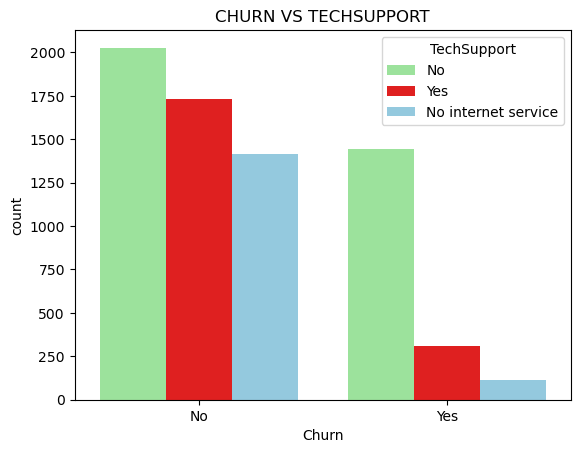

In [46]:
sns.countplot(x ='Churn',hue = 'TechSupport',data = df, palette=('lightgreen','red','skyblue'))
plt.title("CHURN VS TECHSUPPORT")

- BY THIS PLOT WE CAN OBSERVE THAT,THE CUSTOMERS WITH TECH SUPPORT ARE HAVING LESS CHURN AND HIGH RETENTION RATE
- CUSTOMERS WITHOUT TECH SUPPORT ARE CHURNED MORE BY LARGELY AROUND 1500(42%)
- CUSTOMERS WITHOUT INTERNET CONNECTION ARE CHURNED LESS COMPARED TO BOTH CASES

### INSIGHT:
- TECH SUPPORT IS STRONGLY EFFECTING THE CUSTOMER CHURN
- CUSTOMER WITH TECHNICAL SUPPORT ARE CHURNED LESS
- CUSTOMERS WITHOUT TECHNICAL SUPPORT ARE CHURNED HIGH

# Contract VS Churn

In [47]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### - The customers with two-year contract are having less than 3% churn rate.
### - But with month-to-month contract are having very high churn rate around 43%.
### - And one year contract customers are also having low churn rate around 11%.

Text(0.5, 1.0, 'CHURN VS CONTRACT')

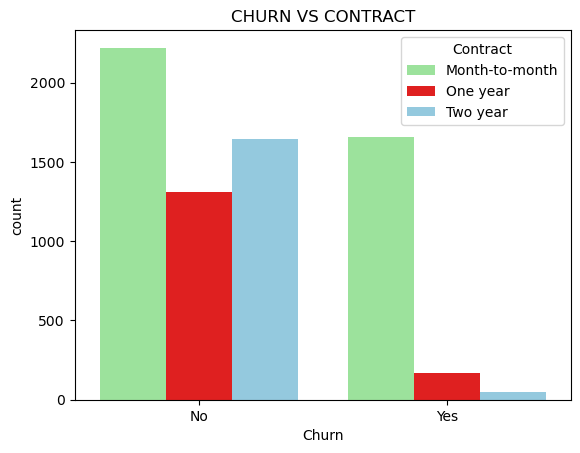

In [48]:
sns.countplot(x ='Churn',hue = 'Contract',data = df, palette=('lightgreen','red','skyblue'))
plt.title("CHURN VS CONTRACT")

- HERE IT WAS SHOWING CLEARLY THAT TWO-YEAR CONTRACT CUSTOMERS HAVE LESS CHURN
- AND ALSO WITH ONE-YEAR CONTRACT CUSTOMERS THE CHURN IS LESS NOT THAT MUCH HIGH COMPARED TO THE MONTHLY CONTRACT CUSTOMERS

### INSIGHT:
- CONTRACT IS INFLUENCING THE CUSTOMER CHURN VERY STRONGLY
- CONTRACT IS MORE THAN ONE YAER THE CHURN RATE WILL DECREASE

# PaperlessBilling VS Churn

In [49]:
pd.crosstab(df['PaperlessBilling'],df['Churn'],normalize='index')*100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


### - Here the customers receiving their bills in online are Churned more(34%).
### - Whereas the customers without PaperlessBilling are less Churned around(16%).

Text(0.5, 1.0, 'CHURN VS PAPERLESSBILLING')

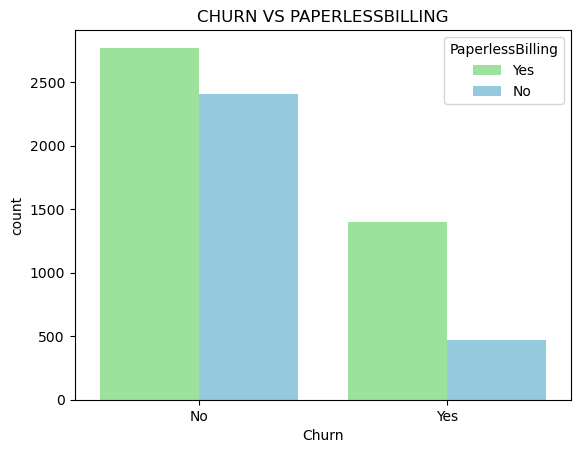

In [50]:
sns.countplot(x ='Churn',hue = 'PaperlessBilling',data = df, palette=('lightgreen','skyblue'))
plt.title("CHURN VS PAPERLESSBILLING")

- customers with paperlessbilling are having highest churn rate
- customers without paperlessbilling are having less churn

### INSIGHTS:
- PAPERLESSBILLING IS MODERATELY INFLUENCING THE CUSTOMER CHURN
- WITHOUT PAPERLESSBILLING THE CHURN RATE IS LESS

# PaymentMethod VS Churn

In [51]:
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### - Customers paying bill using electronic check are more Churned(45%) compared to other categories.
### - The remaining categories are very similarly Churned and has less Churn rate arround(15-20%).

Text(0.5, 1.0, 'CHURN VS PAPERLESSBILLING')

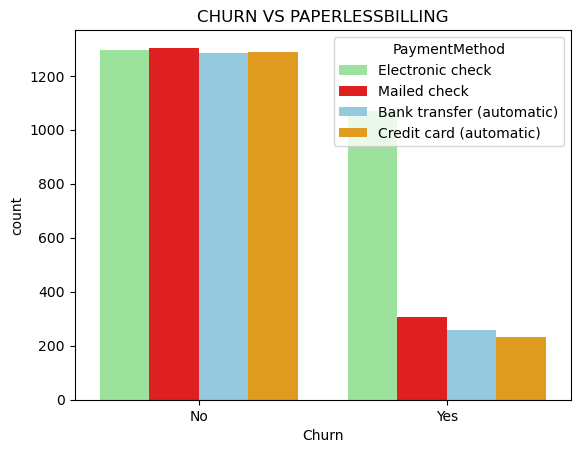

In [52]:
sns.countplot(x ='Churn',hue = 'PaymentMethod',data = df, palette=('lightgreen','red','skyblue','orange'))
plt.title("CHURN VS PAPERLESSBILLING")

- THE CUSTOMERS ARE EQUALLY RETAINED IN ALL CASES AND ALSO THEY ARE EQUALLY DISTRIBUTED
- THE CHURN IS MORE IN THE ELECTRONIC CHECK PAYMENT METHOD
- AND REMAINING THREE CATEGORIES ARE QUITE SIMILAR IN CHURN RATE

### INSIGHT:
- PAYMENT METHOD IS MODERATELY INFLUENCING THE CUSTOMER CHURN
- CUSTOMERS USING ELECTRONIC CHECK SHOW HIGHER CHURN RATES. THE COMPANY SHOULD INVESTIGATE THE REASONS AND ENCOURAGE THE ADOPTION OF ALTERNATIVE PAYMENT METHODS

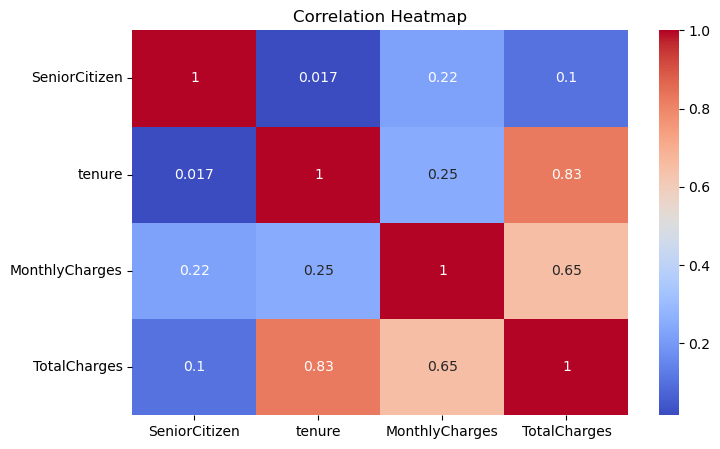

In [53]:
corr_df = df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']]
plt.figure(figsize=(8,5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### - Tenure shows a negative relationship with churn, indicating that customers with longer tenure are less likely to churn. Monthly charges exhibit a positive relationship with churn, while Total Charges are strongly associated with tenure

### KEY INSIGHTS:

1. **CUSTOMERS WITH LOWER TENURE ARE MORE LIKELY TO CHURN**, INDICATING THAT CUSTOMER ATTRITION IS HIGHEST DURING THE EARLY STAGES OF THE CUSTOMER LIFECYCLE.
2. **CUSTOMERS SUBSCRIBED TO MONTH-TO-MONTH CONTRACTS** EXHIBIT SIGNIFICANTLY HIGHER CHURN RATES COMPARED TO CUSTOMERS WITH ONE-YEAR AND TWO-YEAR CONTRACTS.
3. **FIBER OPTIC INTERNET USERS** SHOW A HIGHER TENDENCY TO CHURN THAN CUSTOMERS USING DSL OR THOSE WITHOUT INTERNET SERVICE.
4. **CUSTOMERS WITHOUT ONLINE SECURITY AND TECH SUPPORT SERVICES** ARE MORE LIKELY TO CHURN, SUGGESTING THAT VALUE-ADDED SERVICES CONTRIBUTE POSITIVELY TO CUSTOMER RETENTION.
5. **CUSTOMERS WITH HIGHER MONTHLY CHARGES** EXHIBIT HIGHER CHURN RATES, INDICATING THAT PRICING MAY INFLUENCE CUSTOMER RETENTION DECISIONS.
6. **CUSTOMERS USING ELECTRONIC CHECK** AS THEIR PAYMENT METHOD EXPERIENCE HIGHER CHURN RATES COMPARED TO CUSTOMERS USING OTHER PAYMENT METHODS.
7. **DEMOGRAPHIC FACTORS SUCH AS GENDER** HAVE MINIMAL INFLUENCE ON CHURN, WHEREAS SERVICE-RELATED AND CONTRACT-RELATED FACTORS HAVE A MUCH STRONGER IMPACT.
8. **LONG-TENURE CUSTOMERS** DEMONSTRATE HIGHER RETENTION RATES, INDICATING INCREASED CUSTOMER LOYALTY OVER TIME.

# Recommendation
1. **IMPLEMENT TARGETED RETENTION PROGRAMS FOR NEW CUSTOMERS** DURING THEIR FIRST YEAR OF SERVICE TO REDUCE EARLY-STAGE CHURN.
2. **ENCOURAGE CUSTOMERS TO TRANSITION FROM MONTH-TO-MONTH CONTRACTS TO LONG-TERM CONTRACTS** THROUGH DISCOUNTS, LOYALTY REWARDS, OR BUNDLED OFFERS.
3. **INVESTIGATE THE REASONS BEHIND THE HIGH CHURN RATE AMONG FIBER OPTIC CUSTOMERS** AND TAKE CORRECTIVE ACTIONS TO IMPROVE SERVICE QUALITY AND CUSTOMER SATISFACTION.
4. **PROMOTE ONLINE SECURITY AND TECH SUPPORT SERVICES** THROUGH BUNDLED PACKAGES AND PROMOTIONAL CAMPAIGNS TO INCREASE CUSTOMER ENGAGEMENT AND RETENTION.
5. **REVIEW PRICING STRATEGIES FOR CUSTOMERS WITH HIGH MONTHLY CHARGES** AND INTRODUCE PERSONALIZED OFFERS WHERE APPROPRIATE.
6. **ANALYZE CUSTOMER EXPERIENCES ASSOCIATED WITH ELECTRONIC CHECK PAYMENTS** AND ENCOURAGE THE ADOPTION OF ALTERNATIVE PAYMENT METHODS.
7. **DEVELOP LOYALTY PROGRAMS FOR LONG-TERM CUSTOMERS** TO STRENGTHEN CUSTOMER RELATIONSHIPS AND FURTHER IMPROVE RETENTION.
8. **CONTINUOUSLY MONITOR CUSTOMER BEHAVIOR** AND PROACTIVELY IDENTIFY HIGH-RISK CUSTOMERS FOR TARGETED RETENTION INITIATIVES.



### CONCLUSION:
THE ANALYSIS IDENTIFIED TENURE, CONTRACT TYPE, INTERNET SERVICE, VALUE-ADDED SERVICES, MONTHLY CHARGES, AND PAYMENT METHOD AS THE MAJOR FACTORS INFLUENCING CUSTOMER CHURN. BY FOCUSING ON CUSTOMER RETENTION STRATEGIES, SERVICE QUALITY IMPROVEMENTS, AND LONG-TERM CUSTOMER ENGAGEMENT, THE COMPANY CAN REDUCE CHURN AND IMPROVE CUSTOMER LOYALTY.